In [1]:
import pandas as pd

df = pd.read_csv('/content/superstore.csv')

print(df.shape)
df.head()

(10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,10/11/2016,10/18/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


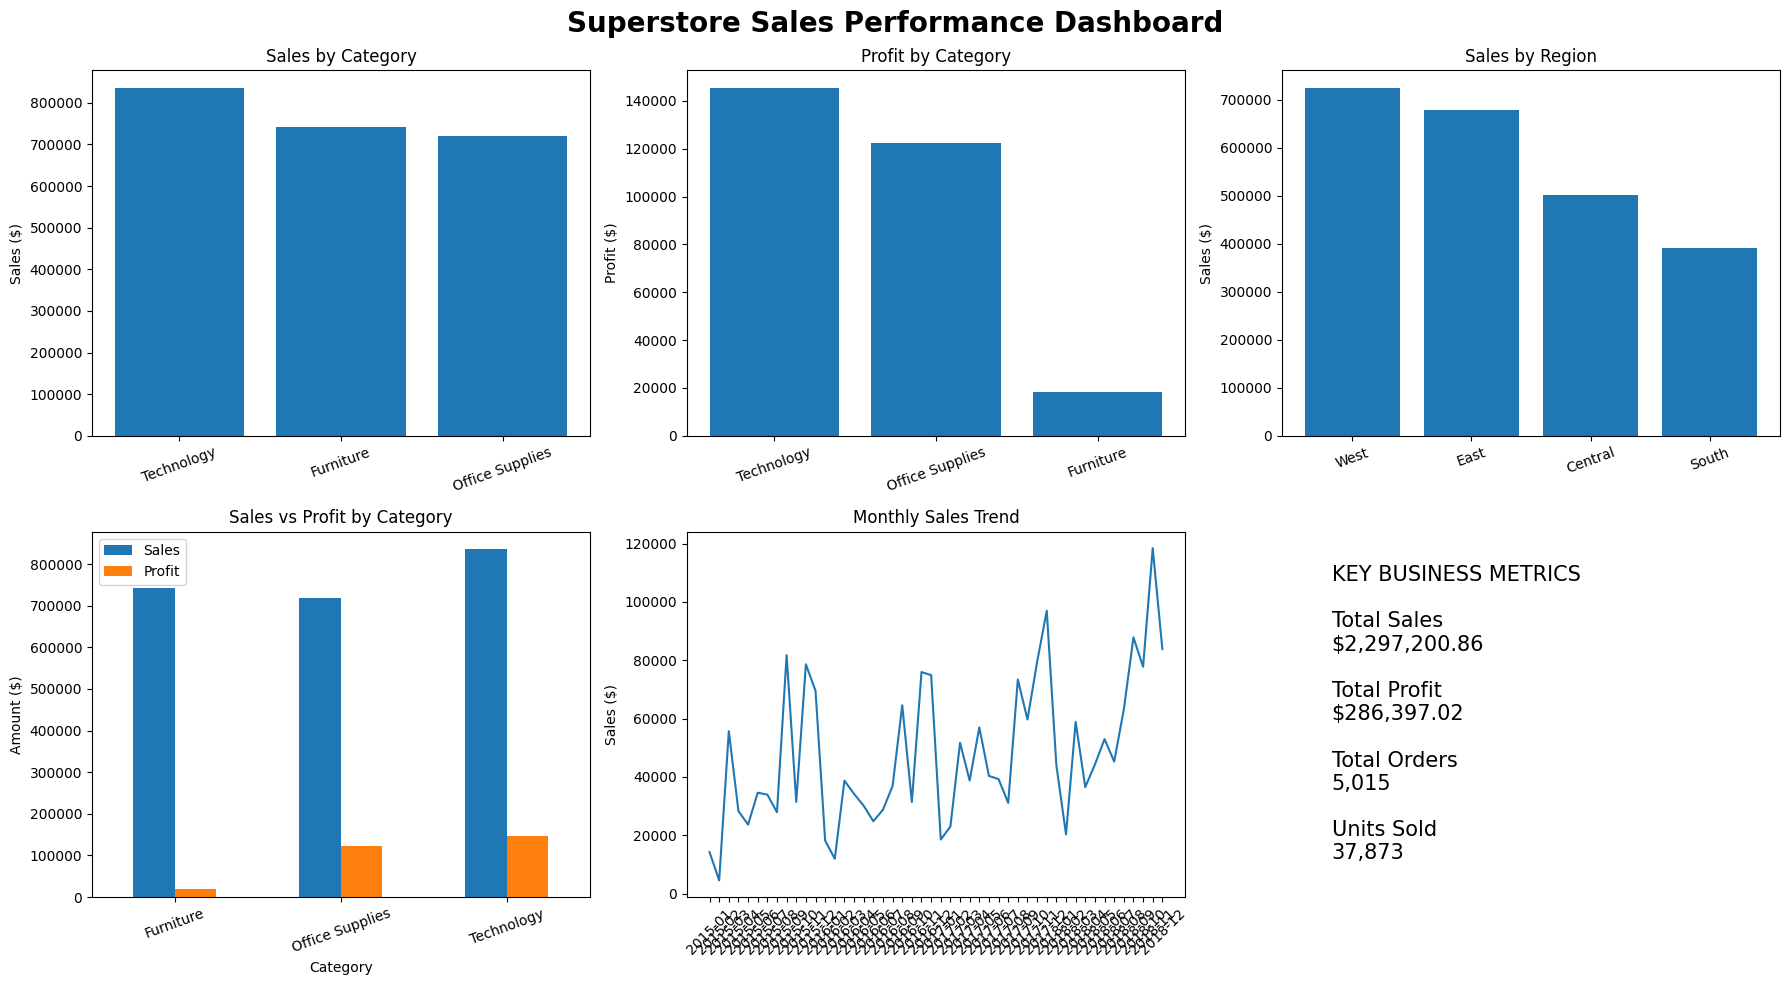

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create a 2x3 dashboard
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Sales by Category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

axes[0, 0].bar(category_sales.index, category_sales.values)
axes[0, 0].set_title('Sales by Category')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].tick_params(axis='x', rotation=20)

# 2. Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

axes[0, 1].bar(category_profit.index, category_profit.values)
axes[0, 1].set_title('Profit by Category')
axes[0, 1].set_ylabel('Profit ($)')
axes[0, 1].tick_params(axis='x', rotation=20)

# 3. Sales by Region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

axes[0, 2].bar(region_sales.index, region_sales.values)
axes[0, 2].set_title('Sales by Region')
axes[0, 2].set_ylabel('Sales ($)')
axes[0, 2].tick_params(axis='x', rotation=20)

# 4. Sales vs Profit by Category
category_data = df.groupby('Category')[['Sales', 'Profit']].sum()

category_data.plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Sales vs Profit by Category')
axes[1, 0].set_ylabel('Amount ($)')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].legend()

# 5. Monthly Sales Trend
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

axes[1, 1].plot(monthly_sales.index.astype(str), monthly_sales.values)
axes[1, 1].set_title('Monthly Sales Trend')
axes[1, 1].set_ylabel('Sales ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Key Metrics
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_quantity = df['Quantity'].sum()

axes[1, 2].axis('off')

metrics = f"""
KEY BUSINESS METRICS

Total Sales
${total_sales:,.2f}

Total Profit
${total_profit:,.2f}

Total Orders
{total_orders:,}

Units Sold
{total_quantity:,.0f}
"""

axes[1, 2].text(
    0.1, 0.5, metrics,
    fontsize=15,
    verticalalignment='center'
)

plt.suptitle(
    'Superstore Sales Performance Dashboard',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()

# Save dashboard
plt.savefig('superstore_dashboard.png', dpi=300, bbox_inches='tight')

plt.show()